# Spam SMS EDA + Baseline Model

This notebook performs exploratory data analysis (EDA) on the **Spam SMS Collection** dataset and trains a simple baseline model (Bag-of-Words + Multinomial Naive Bayes).

**Includes:** class balance, length distributions, top terms (uni/bi-grams), optional word clouds, confusion matrix, classification report, and most indicative terms.

## Setup

- Dataset file expected at: `Spam SMS Collection` (repo root).
- Optional dependency for word clouds: `wordcloud`

If you need it in this environment, run (in a terminal):

```bash
python -m pip install wordcloud
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
)

DATA_PATH = 'Spam SMS Collection'

plt.rcParams.update({'figure.dpi': 120})

In [2]:
# Load the dataset
df = pd.read_csv(
    DATA_PATH,
    sep='	',
    names=['label', 'message'],
    encoding='latin-1',
)
df['message'] = df['message'].astype(str)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


label
ham     4825
spam     747
Name: count, dtype: int64

label
ham     86.59
spam    13.41
Name: count, dtype: float64

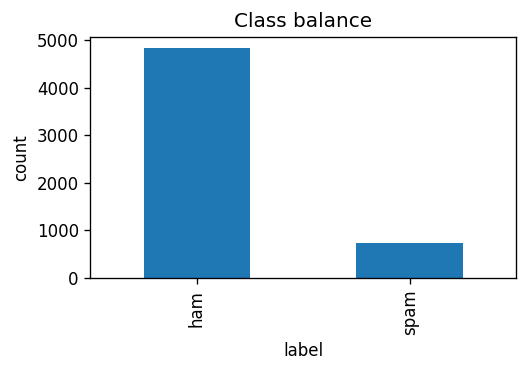

In [3]:
# Class balance
counts = df['label'].value_counts()
display(counts)
display((counts / counts.sum() * 100).round(2))

plt.figure(figsize=(4.5, 3.2))
counts.plot(kind='bar')
plt.title('Class balance')
plt.xlabel('label')
plt.ylabel('count')
plt.tight_layout()
plt.show()

In [4]:
# Simple text-derived features
df['char_len'] = df['message'].str.len()
df['word_len'] = df['message'].str.split().str.len()
df['digit_count'] = df['message'].str.count(r'\d')
df['upper_count'] = df['message'].str.count(r'[A-Z]')

df.groupby('label')[['char_len', 'word_len', 'digit_count', 'upper_count']].agg(['mean', 'median', 'min', 'max']).round(2)

char_len                 word_len                 digit_count         \
          mean median min  max     mean median min  max        mean median   
label                                                                        
ham      71.56   52.0   2  910    14.31   11.0   1  171        0.31    0.0   
spam    139.12  149.0  13  224    23.91   25.0   2   35       15.81   16.0   

              upper_count                  
      min max        mean median min  max  
label                                      
ham     0  23        4.10    2.0   0  138  
spam    0  47       15.47   14.0   0  128

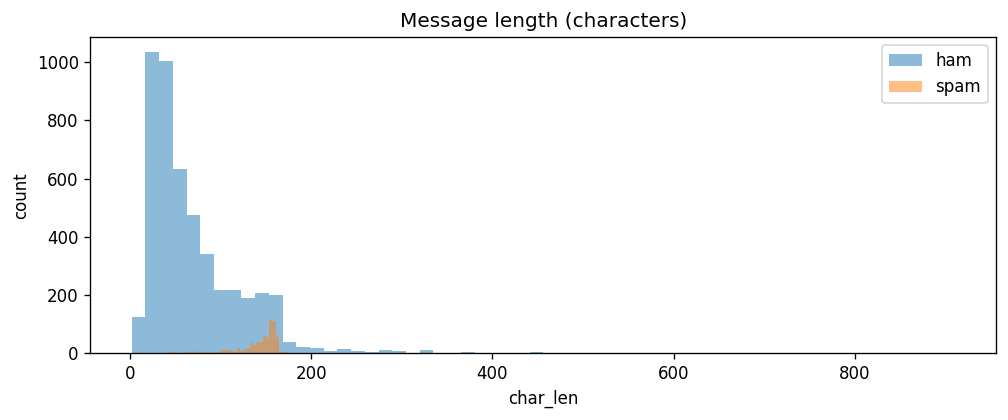

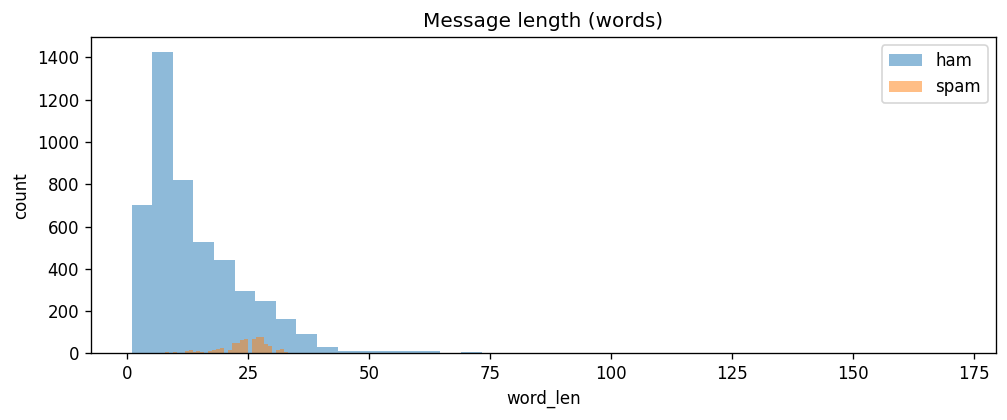

In [5]:
# Message length distributions
plt.figure(figsize=(8.5, 3.6))
for lbl in ['ham', 'spam']:
    subset = df.loc[df['label'] == lbl, 'char_len']
    plt.hist(subset, bins=60, alpha=0.5, label=lbl)
plt.title('Message length (characters)')
plt.xlabel('char_len')
plt.ylabel('count')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8.5, 3.6))
for lbl in ['ham', 'spam']:
    subset = df.loc[df['label'] == lbl, 'word_len']
    plt.hist(subset, bins=40, alpha=0.5, label=lbl)
plt.title('Message length (words)')
plt.xlabel('word_len')
plt.ylabel('count')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# Top terms per class (uni/bi-grams)
def top_terms(texts, n=20, ngrams=(1, 1), min_df=2):
    vec = CountVectorizer(stop_words='english', ngram_range=ngrams, min_df=min_df)
    X = vec.fit_transform(texts)
    freqs = np.asarray(X.sum(axis=0)).ravel()
    terms = vec.get_feature_names_out()
    idx = freqs.argsort()[::-1][:n]
    return list(zip(terms[idx], freqs[idx].astype(int)))

spam_texts = df.loc[df['label'] == 'spam', 'message']
ham_texts = df.loc[df['label'] == 'ham', 'message']

print('Top spam unigrams:', top_terms(spam_texts, n=20, ngrams=(1, 1)))
print('Top ham  unigrams:', top_terms(ham_texts, n=20, ngrams=(1, 1)))
print('Top spam bigrams :', top_terms(spam_texts, n=20, ngrams=(2, 2)))
print('Top ham  bigrams :', top_terms(ham_texts, n=20, ngrams=(2, 2)))

Top spam unigrams: [('free', np.int64(224)), ('txt', np.int64(163)), ('ur', np.int64(144)), ('mobile', np.int64(127)), ('text', np.int64(125)), ('stop', np.int64(123)), ('claim', np.int64(113)), ('reply', np.int64(104)), ('www', np.int64(98)), ('prize', np.int64(93)), ('just', np.int64(79)), ('won', np.int64(76)), ('cash', np.int64(76)), ('uk', np.int64(74)), ('150p', np.int64(71)), ('send', np.int64(71)), ('new', np.int64(69)), ('nokia', np.int64(67)), ('win', np.int64(64)), ('urgent', np.int64(63))]
Top ham  unigrams: [('gt', np.int64(318)), ('lt', np.int64(316)), ('just', np.int64(297)), ('ok', np.int64(288)), ('ll', np.int64(266)), ('ur', np.int64(247)), ('know', np.int64(237)), ('good', np.int64(235)), ('like', np.int64(234)), ('got', np.int64(233)), ('come', np.int64(230)), ('day', np.int64(212)), ('love', np.int64(205)), ('time', np.int64(202)), ('going', np.int64(169)), ('home', np.int64(165)), ('want', np.int64(165)), ('lor', np.int64(162)), ('need', np.int64(159)), ('sorry', 

In [7]:
# Optional: Word clouds
try:
    from wordcloud import WordCloud, STOPWORDS

    stop = set(STOPWORDS)
    for lbl in ['ham', 'spam']:
        text = ' '.join(df.loc[df['label'] == lbl, 'message'].str.lower())
        wc = WordCloud(
            width=900,
            height=450,
            background_color='white',
            stopwords=stop,
            collocations=False,
        ).generate(text)

        plt.figure(figsize=(12, 5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'{lbl} word cloud')
        plt.tight_layout()
        plt.show()
except ImportError:
    print('WordCloud not installed. Install with: python -m pip install wordcloud')

WordCloud not installed. Install with: python -m pip install wordcloud


## Baseline Model

We train a simple baseline using:
- `CountVectorizer(max_features=2500, stop_words="english")`
- `MultinomialNB(alpha=0.3)`

Then we evaluate with a confusion matrix and classification report.

Accuracy: 0.97847533632287
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       966
        spam       0.94      0.90      0.92       149

    accuracy                           0.98      1115
   macro avg       0.96      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



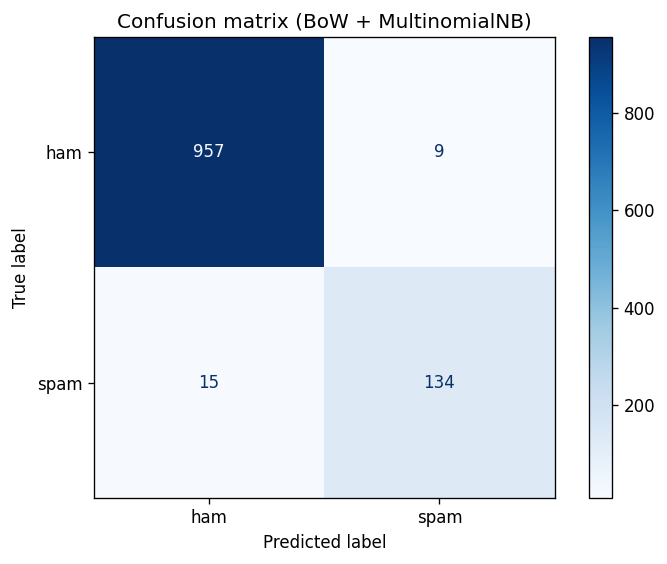

In [8]:
X = df['message']
y = df['label'].map({'ham': 0, 'spam': 1}).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

model = Pipeline([
    ('vect', CountVectorizer(max_features=2500, stop_words='english')),
    ('clf', MultinomialNB(alpha=0.3)),
])

model.fit(X_train, y_train)
pred = model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, pred))
print(classification_report(y_test, pred, target_names=['ham', 'spam']))

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham', 'spam'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion matrix (BoW + MultinomialNB)')
plt.tight_layout()
plt.show()

In [9]:
# Most indicative terms (what NB associates with spam vs ham)
vect = model.named_steps['vect']
clf = model.named_steps['clf']
feature_names = np.array(vect.get_feature_names_out())

spam_score = clf.feature_log_prob_[1] - clf.feature_log_prob_[0]
ham_score = clf.feature_log_prob_[0] - clf.feature_log_prob_[1]

top_spam = feature_names[np.argsort(spam_score)[::-1][:20]].tolist()
top_ham = feature_names[np.argsort(ham_score)[::-1][:20]].tolist()

print('Most spam-indicative terms:', top_spam)
print('Most ham-indicative terms :', top_ham)

Most spam-indicative terms: ['claim', 'prize', '150p', 'tone', '18', 'guaranteed', '500', 'cs', 'awarded', '1000', '000', 'entry', '150ppm', 'ringtone', 'collection', 'mob', 'tones', '10p', 'valid', '8007']
Most ham-indicative terms : ['gt', 'lt', 'lor', 'da', 'later', 'ã¼', 'doing', 'said', 'ask', 'amp', 'morning', 'cos', 'sure', 'pick', 'lol', 'wait', 'gud', 'sleep', 'nice', 'went']


## Next steps (optional ideas)

- Try `TfidfVectorizer` + Logistic Regression
- Add character n-grams (often helps spam detection)
- Tune NB `alpha` and `max_features`
- Evaluate using precision/recall (spam is often imbalanced)

_Notebook generated by Copilot (EDA + baseline model)._